# FuseMap Tutorial 7: Integrating Datasets Across Conditions (Healthy × Alzheimer's Disease)

Disease datasets differ from healthy references in **two ways at once**: the biology (condition) and usually also the platform/gene panel. This tutorial integrates:

- a **MERFISH** hippocampus section from a 13-month-old **Alzheimer's disease (AD)** mouse model
- a matched **STARmap** hippocampus crop from a **healthy** mouse

FuseMap's anchor-based alignment (enabled by default) pulls shared populations together across the two datasets while a pairwise similarity gate protects condition-specific populations from being forced to mix.

**Runtime**: ~30–60 min on a single GPU. No parameters to set — one function call.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import scanpy as sc

## 1. Download the example data

Two `.h5ad` files (~30 MB total), each with spatial coordinates in `obs['x']/obs['y']` and
author cell-type / tissue-region labels in `obs['celltype_anno']` / `obs['tissueregion_anno']`.

In [ ]:
import gdown

FILES = {
    "13months-disease-replicate_1.h5ad": "1NUGPliw0ZCFxHwgVjjH3Pkm05LjdphaV",
    "precomputed_output/ad_celltype_embedding.h5ad": "1WoRCtLFSv5JeE87b37svArJw4Yg8seoX",
    "precomputed_output/ad_gene_embedding.h5ad": "1kYgISJgRMqgfiXnOwjuPxyAFHtvhs4KU",
    "precomputed_output/ad_tissueregion_embedding.h5ad": "1kgVTciH1kXJYYvANAsx3yA-Sqwy15Kfk",
    "section1.h5ad": "1dBPYDHLp7S6XDpq-t1GcNNCbyYsd4uoO",
}
base = "./tutorial_data/tutorial7_cross_condition"
for rel, fid in FILES.items():
    out = os.path.join(base, rel)
    if not os.path.exists(out):
        os.makedirs(os.path.dirname(out), exist_ok=True)
        gdown.download(id=fid, output=out, quiet=False)

## 2. Integrate — one call

`fusemap.integrate` reads every `.h5ad` in the folder, builds spatial graphs, trains the model,
and writes the universal embeddings to the output folder. If interrupted, re-running the same
call resumes from the last epoch automatically.

In [3]:
import fusemap

fusemap.integrate("./tutorial_data/tutorial7_cross_condition", "./output_tutorial7",
                  keep_celltype="celltype_anno", keep_tissueregion="tissueregion_anno")

2026-09-04 22:10:25,385 - INFO - Arguments: {'output_save_dir': './output_tutorial7', 'keep_celltype': 'celltype_anno', 'keep_tissueregion': 'tissueregion_anno', 'use_llm_gene_embedding': 'false', 'pretrain_model_path': ''}


2026-09-04 22:10:26,985 - INFO - 

---------------------------------- Preprocess adata ----------------------------------



2026-09-04 22:10:31,404 - INFO - 

---------------------------------- Construct graph adata ----------------------------------



2026-09-04 22:10:31,510 - INFO - 

---------------------------------- Process graph adata ----------------------------------



2026-09-04 22:10:31,921 - INFO - 

number of genes in each section:[2715, 1022], Number of all genes: 2831.



...

2026-09-04 22:10:32,995 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=8, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-04 22:10:32,996 - INFO - [FuseMap loader] atlas 0: dense CPU feature cache ENABLED (10372 x 2715 = 0.105 GB < 2.0 GB limit); per-batch slicing uses torch row indexing.


2026-09-04 22:10:33,115 - INFO - [FuseMap loader] atlas 1: dense CPU feature cache ENABLED (9002 x 1022 = 0.034 GB < 2.0 GB limit); per-batch slicing uses torch row indexing.


2026-09-04 22:10:33,152 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=8, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-04 22:10:33,161 - INFO - 

---------------------------------- Finish ----------------------------------



## 3. Inspect the integrated cell embedding

Sections should interleave in the UMAP while cell types stay separated. Note how shared types
(e.g. dentate gyrus granule neurons) from the AD and healthy sections co-cluster, even though
they come from different platforms *and* conditions.

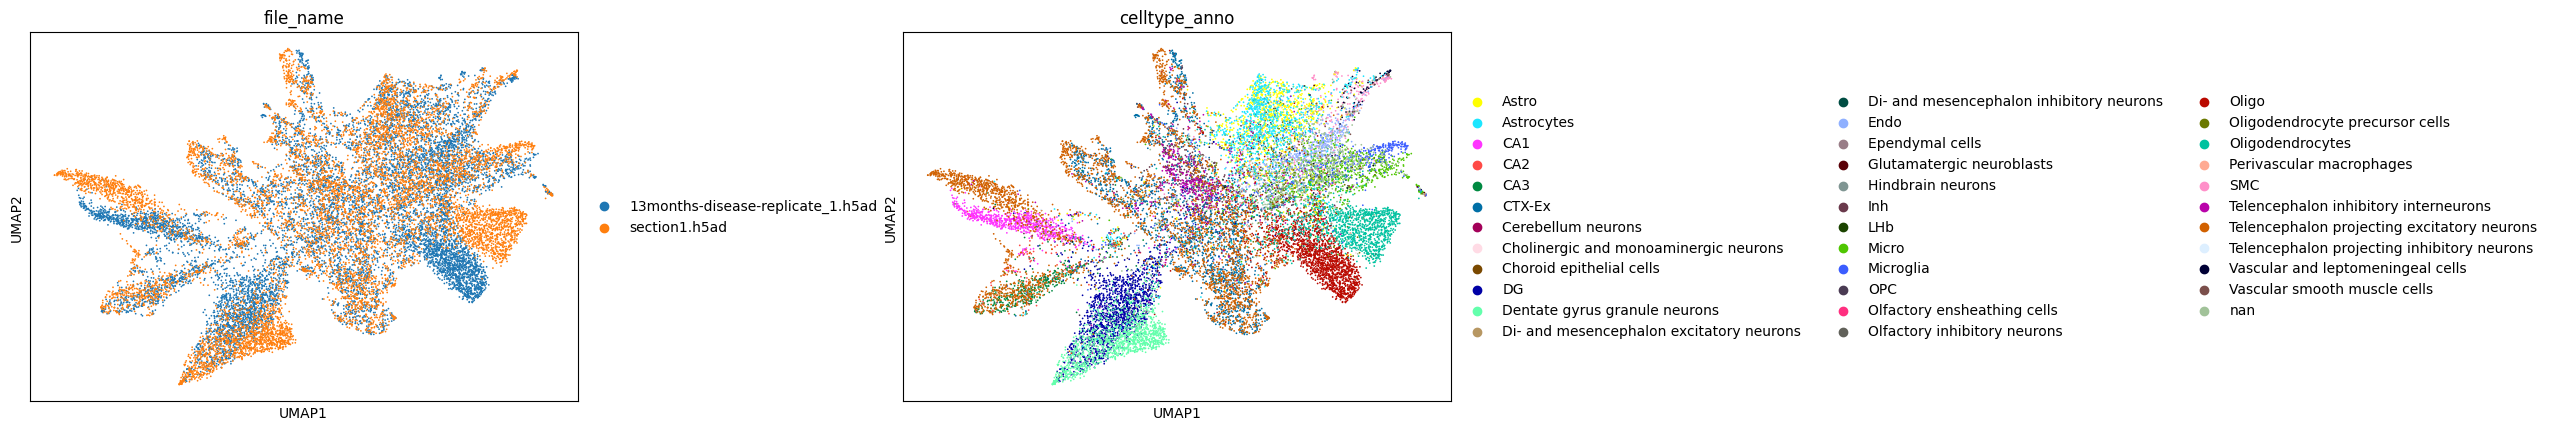

In [4]:
ad_cell = sc.read_h5ad("./output_tutorial7/ad_celltype_embedding.h5ad")

sc.pp.neighbors(ad_cell, use_rep="X", n_neighbors=50)
sc.tl.umap(ad_cell)
sc.pl.umap(ad_cell, color=["file_name", "celltype_anno"], wspace=0.45)

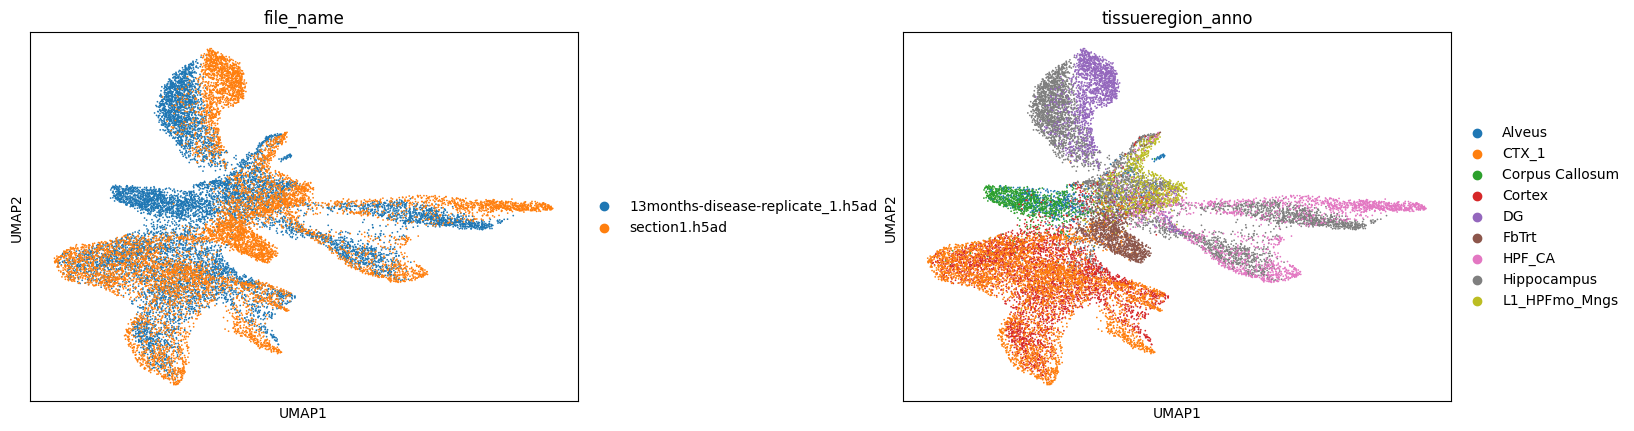

In [5]:
ad_tissue = sc.read_h5ad("./output_tutorial7/ad_tissueregion_embedding.h5ad")

sc.pp.neighbors(ad_tissue, use_rep="X", n_neighbors=50)
sc.tl.umap(ad_tissue)
sc.pl.umap(ad_tissue, color=["file_name", "tissueregion_anno"], wspace=0.45)

## 4. Tissue regions back in space

Cluster the tissue embedding jointly, then color each section's cells by their joint cluster —
matching anatomical structures (DG, CA fields, cortex layers) should get matching clusters in
both conditions.

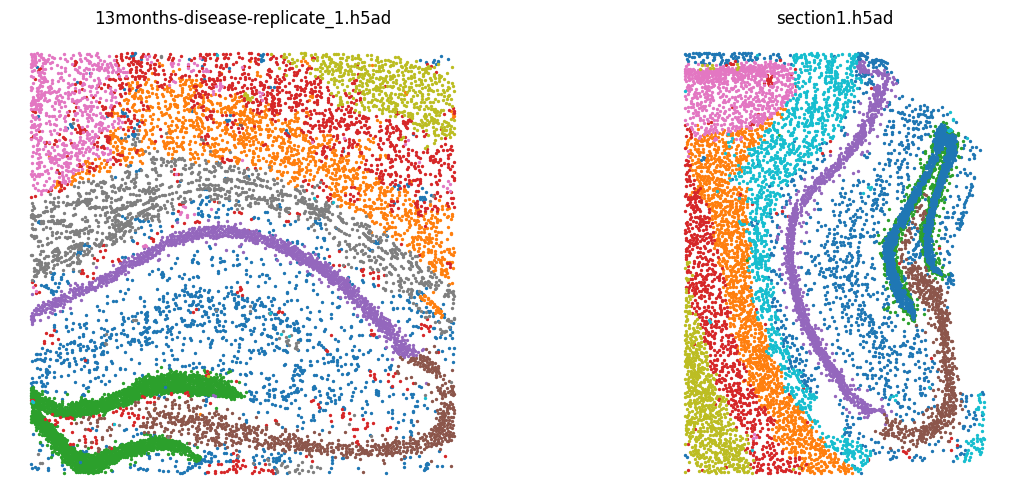

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

sc.tl.leiden(ad_tissue, resolution=0.5, key_added="joint_region")
ad_tissue.obs["x"] = pd.to_numeric(ad_tissue.obs["x"])
ad_tissue.obs["y"] = pd.to_numeric(ad_tissue.obs["y"])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fn in zip(axes, ad_tissue.obs["file_name"].unique()):
    sub = ad_tissue.obs[ad_tissue.obs["file_name"] == fn]
    for cl in sub["joint_region"].cat.categories:
        m = sub["joint_region"] == cl
        ax.scatter(sub["x"][m], sub["y"][m], s=2)
    ax.set_title(fn); ax.set_aspect("equal"); ax.axis("off")
plt.show()

## Notes

- **Reproduce the original (non-anchored) FuseMap**: set the environment variable
  `FUSEMAP_ANCHOR_LAMBDA=0` before calling `fusemap.integrate` — see the
  [Parameters](https://fusemap.readthedocs.io/en/latest/userguide/parameters.html) page.
- For very rare cell types (<1% of cells), we recommend also running a `FUSEMAP_ANCHOR_LAMBDA=0`
  companion and comparing.
- A precomputed `precomputed_output/` folder ships with the download if you want to skip training.